In [3]:
import numpy as np
import pandas as pd
np.random.seed(44)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", palette="rainbow")
import warnings
from matplotlib.offsetbox import AnchoredText
warnings.filterwarnings("ignore")

In [2]:
sizes = [10, 20, 50, 100]
apriori = ['apriori', 'reopt']

sampling = ['greedy', 'sampling','beam']
knn = ['const_demand', 'knn_demand']
fixed = ['flex_posit', 'fixed_posit']
terms = ['1', '2', '3', '4']
filling = ['fil_1','fil_5','fil_9']
partial = ['full','partial']

In [10]:
def read(list_):
    
    output = ''
    all_values = {}
    for key in list_:
        all_values[key] = {}
        for size in sizes:
            all_values[key][size] = {}
            for apr in apriori:           
                values = np.loadtxt('csvs/' + str(size) + '_' + apr + '_' + key + ".txt")
                all_values[key][size][apr] = values
                best = min(values)
                output = output + ' & \\textbf{' + str(round(best, 2)) + '}'
        output = output + ' \\' + '\ \n'
                
    return all_values, output
            
all_values, output = read(fixed)

In [11]:
print(output)

 & \textbf{3.51} & \textbf{3.4} & \textbf{7.16} & \textbf{6.95} & \textbf{14.93} & \textbf{14.48} & \textbf{32.78} & \textbf{31.8} \\ 
 & \textbf{3.13} & \textbf{3.04} & \textbf{6.39} & \textbf{6.2} & \textbf{13.33} & \textbf{12.93} & \textbf{29.27} & \textbf{28.39} \\ 



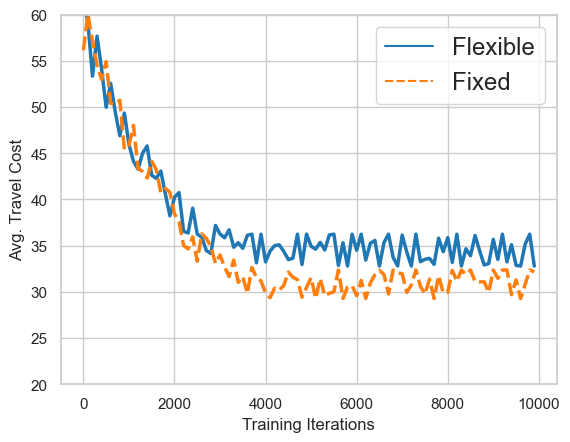

In [12]:
keys = ['flex_posit', 'fixed_posit']
v1 = all_values[keys[0]][100]['apriori']
v2 = all_values[keys[1]][100]['apriori']
v3 = [100*i for i in range(100)]

data = pd.DataFrame({'Flexible':v1,'Fixed':v2})
resplot = sns.lineplot(data=data, palette="tab10", linewidth=2.5)
resplot.set_xticklabels(['', '0', '2000', '4000', '6000', '8000', '10000'])

# resplot.set(xticklabels=[])
resplot.set(xlabel ="Training Iterations", ylabel ="Avg. Travel Cost")

plt.ylim([20,60]) # _50_15
plt.legend(fontsize='x-large', title_fontsize='40')
plt.savefig("plots/position_apriori.pdf", format="pdf", bbox_extra_artists=(resplot,), bbox_inches='tight')



In [16]:
tables_plot_main = pd.DataFrame(columns=['Models', 'Problem Size', 'Correlated to Uncorrelated gap (in percent %)'])
sizes = [10, 20, 50, 100]
models = ['RL_apriori', 'RL_reopt', 'ACO', 'Tabu', 'CW']

rl_apriori = [1.66, 1.30, 1.71, 1.59]
rl_reopt = [2.37, 2.16, 2.07, 2.07]
aco = [0.85, 0.02, -0.03, -1.07]
tabu = [0.11, -0.22, -1.24, -2.32]
cw = [-1.49, -1.73, -2.46, -3.96]

data = [rl_apriori, rl_reopt, aco, tabu, cw]

for i in range(5):
    model_data = data[i]
    model_name = models[i]
    
    for j in range(4):
        size = sizes[j]
        size_data = model_data[j]
        loc = len(tables_plot_main)
        tables_plot_main.loc[loc] = [model_name, size, size_data]



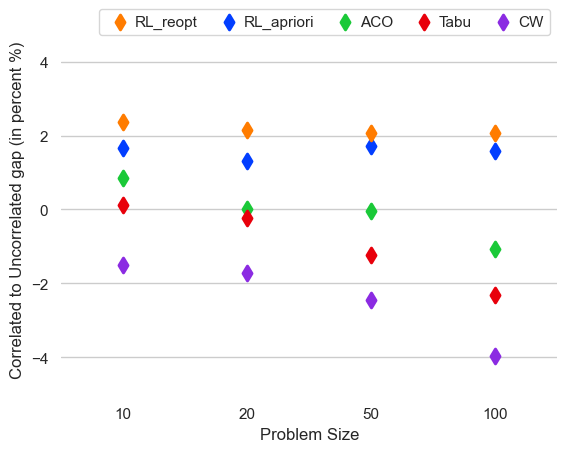

In [15]:
f, ax = plt.subplots()
sns.despine(bottom=True, left=True)

sns.stripplot(x="Problem Size", y="Correlated to Uncorrelated gap (in percent %)", hue="Models",
              data=tables_plot_main, dodge=False, alpha=0.0, zorder=1)

sns.pointplot(x="Problem Size", y="Correlated to Uncorrelated gap (in percent %)", hue="Models",
              data=tables_plot_main, dodge=False,
              join=False, palette="bright",
              markers="d", scale=1.1, ci=None)

handles, labels = ax.get_legend_handles_labels()
lgd = ax.legend([handles[6]] + [handles[5]] + handles[7:], [labels[6]] + [labels[5]] + labels[7:], title="",
          handletextpad=0, columnspacing=1,
          loc="lower right", bbox_to_anchor=(1.00, 0.95), ncol=5, frameon=True)

plt.ylim(-5, 5)
plt.savefig("plots/main_plot.pdf", format="pdf", bbox_extra_artists=(lgd,), bbox_inches='tight')
